# 05 - Clustering (Unsupervised Machine Learning)

**Input:** `student_processed.csv` (created in `01_preprocessing_eda.ipynb`)

**Goal:** discover natural groups of students **without using the target variable** `G3`, choose the number of clusters with the **elbow method** (cross-checked with the silhouette score), visualize the clusters, and translate them into practical insights.

**Methodological notes**
- `G3` is **excluded** from the clustering features. It is used only *after* clustering, to describe and validate the groups.
- There is no prediction target, so no train/test split is needed. The leakage rule still applies to preprocessing: the `absences` cap and the scaler are fitted inside one `Pipeline` and are applied to the same data they were learned from, never to information from outside the dataset.
- K-Means works with distances between continuous values, so it is fitted on the **numerical and ordinal** features (grades, study habits, free time, alcohol use, parental education, and so on). The binary and one-hot columns are not used for fitting (they are not meaningful on a distance scale), but they are used afterwards to **profile** the clusters.

## 1. Setup & Data Loading

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_samples, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

DATA_PATH = Path("../data/student_processed.csv")

df = pd.read_csv(DATA_PATH)
assert df.isnull().sum().sum() == 0
print(f"Loaded {DATA_PATH.resolve()} - shape: {df.shape}")

Loaded A:\US\Semestr5\Szkoła Zimowa\Projekt\Repo\Data-science\data\student_processed.csv - shape: (395, 44)


### Custom transformer: outlier capping learned from the data

In [3]:
class QuantileCapper(BaseEstimator, TransformerMixin):
    """Cap (winsorize) the upper tail of selected columns at a quantile learned from the training data.

    The cap is computed in fit() and applied in transform(), so test data never influences it.
    """

    def __init__(self, columns, quantile=0.95):
        self.columns = columns
        self.quantile = quantile

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.caps_ = {c: np.floor(X[c].quantile(self.quantile)) for c in self.columns}
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for c, cap in self.caps_.items():
            X[c] = X[c].clip(upper=cap)
        return X

    def get_feature_names_out(self, input_features=None):
        names = input_features if input_features is not None else self.feature_names_in_
        return np.asarray(names, dtype=object)

## 2. Feature Selection & Preprocessing

**Clustering features (15):** `age`, `Medu`, `Fedu`, `traveltime`, `studytime`, `failures`, `famrel`, `freetime`, `goout`, `Dalc`, `Walc`, `health`, `absences`, `G1`, `G2`.

Not used for fitting: `G3` (target), `past_grades` and `study_to_free_ratio` (derived from features that are already included, so they would count the same information twice), and the binary/one-hot columns.

`absences` is capped at its 95th percentile and all features are standardized, so that every feature has equal influence on the distances.

Feature matrix: (395, 15) | absences capped at 18


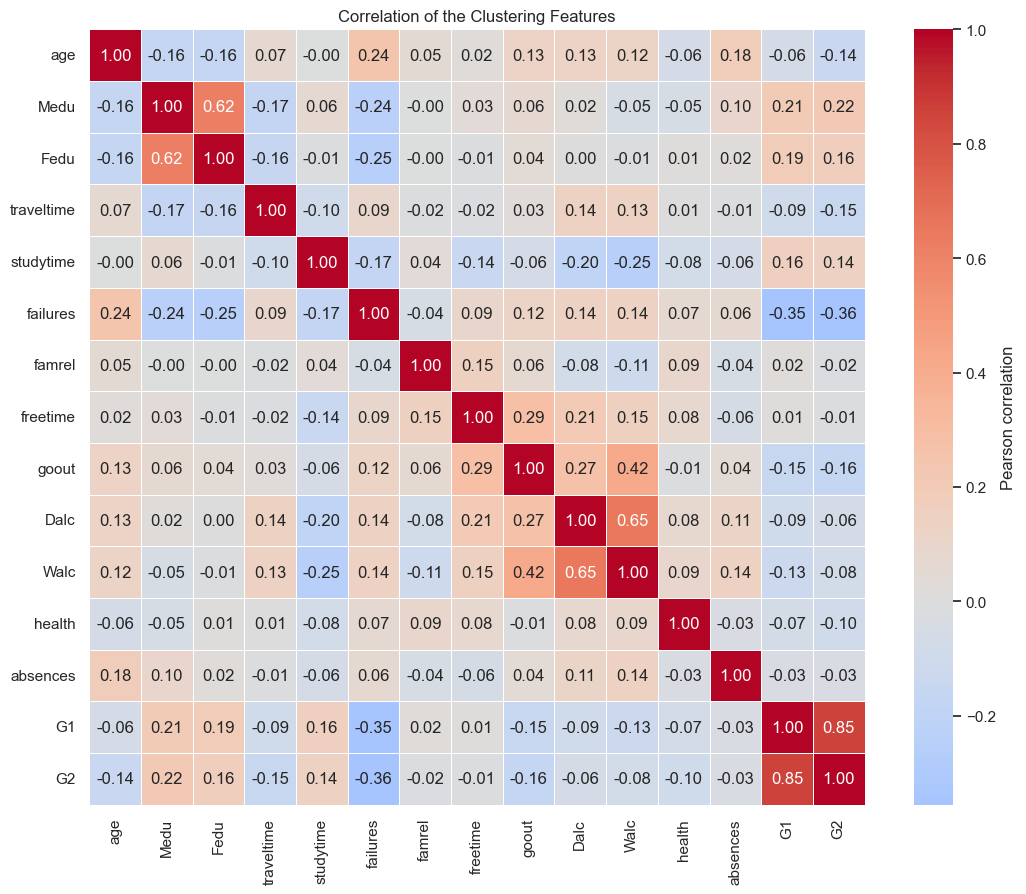

In [4]:
CLUSTER_FEATURES = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures", "famrel", "freetime",
                    "goout", "Dalc", "Walc", "health", "absences", "G1", "G2"]

preprocess = Pipeline([
    ("cap", QuantileCapper(columns=["absences"], quantile=0.95)),
    ("scale", StandardScaler()),
])
X_scaled = preprocess.fit_transform(df[CLUSTER_FEATURES])
print(f"Feature matrix: {X_scaled.shape} | absences capped at {preprocess.named_steps['cap'].caps_['absences']:.0f}")

# Correlation structure of the clustering features
plt.figure(figsize=(11, 9))
sns.heatmap(df[CLUSTER_FEATURES].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.4, cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation of the Clustering Features")
plt.tight_layout()
plt.show()

## 3. Choosing the Number of Clusters

We fit K-Means for k = 2 ... 10 and compute:
- **Inertia** (within-cluster sum of squares) for the **elbow method**. The elbow is located automatically as the point farthest from the straight line connecting the first and last points of the curve.
- The **silhouette score** (from -1 to 1; higher means better separated clusters) as a cross-check.

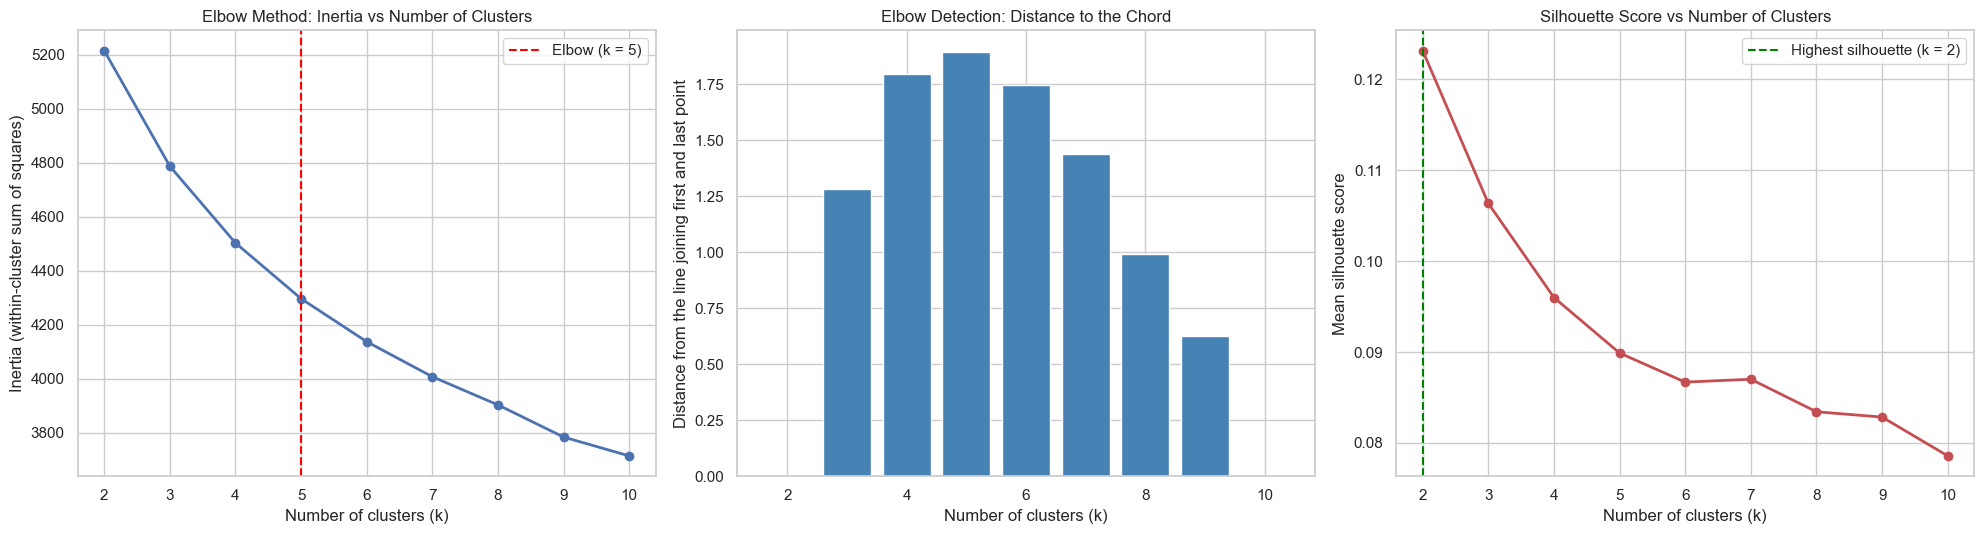

,k,inertia,silhouette,elbow_distance
0,2,5214.500,0.123,0.000
1,3,4786.442,0.106,1.282
2,4,4502.324,0.096,1.797
3,5,4295.993,0.090,1.897
4,6,4136.746,0.087,1.746
5,7,4007.038,0.087,1.437
6,8,3902.705,0.083,0.994
7,9,3783.686,0.083,0.628
8,10,3713.937,0.079,0.000


In [5]:
K_RANGE = list(range(2, 11))
inertias, silhouettes = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

# Elbow: point with the largest perpendicular distance to the chord between the first and last point
pts = np.column_stack([K_RANGE, inertias]).astype(float)
chord = (pts[-1] - pts[0]) / np.linalg.norm(pts[-1] - pts[0])
rel = pts - pts[0]
elbow_dist = np.abs(rel[:, 0] * chord[1] - rel[:, 1] * chord[0])
elbow_k = K_RANGE[int(np.argmax(elbow_dist))]
best_sil_k = K_RANGE[int(np.argmax(silhouettes))]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
axes[0].plot(K_RANGE, inertias, "bo-", lw=2)
axes[0].axvline(elbow_k, color="red", linestyle="--", label=f"Elbow (k = {elbow_k})")
axes[0].set_title("Elbow Method: Inertia vs Number of Clusters")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster sum of squares)")
axes[0].legend()

axes[1].bar(K_RANGE, elbow_dist, color="steelblue")
axes[1].set_title("Elbow Detection: Distance to the Chord")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Distance from the line joining first and last point")

axes[2].plot(K_RANGE, silhouettes, "ro-", lw=2)
axes[2].axvline(best_sil_k, color="green", linestyle="--", label=f"Highest silhouette (k = {best_sil_k})")
axes[2].set_title("Silhouette Score vs Number of Clusters")
axes[2].set_xlabel("Number of clusters (k)")
axes[2].set_ylabel("Mean silhouette score")
axes[2].legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"k": K_RANGE, "inertia": inertias, "silhouette": silhouettes, "elbow_distance": elbow_dist}).round(3)

**Decision.** Both criteria are weak here, which is itself a finding: the inertia curve decreases smoothly with no sharp elbow (the automatic detection peaks at k = 5, but k = 4-6 are almost tied), and the silhouette score is highest for k = 2 and then declines steadily; all values are low (about 0.1). The students therefore do **not** form clearly separated groups, and the clusters should be read as *tendencies*, not hard categories.

Because the criteria disagree, the final choice is a judgement call: we use **k = 3**. It is a compromise between the silhouette score (which favours fewer clusters) and the elbow (which favours more), and unlike k = 2 it separates students with the same average grades but very different lifestyles (section 6). The stability check in section 5 quantifies how much to trust this choice.

## 4. Final K-Means Model & Visualization

In [6]:
BEST_K = 3
kmeans = KMeans(n_clusters=BEST_K, n_init=20, random_state=RANDOM_STATE).fit(X_scaled)

# Relabel clusters by increasing mean G2 so that cluster numbers have a stable meaning (0 = lowest grades)
order = pd.Series(df["G2"].groupby(kmeans.labels_).mean()).sort_values().index.tolist()
relabel = {old: new for new, old in enumerate(order)}
labels = np.array([relabel[l] for l in kmeans.labels_])
centers_scaled = kmeans.cluster_centers_[order]

df_clusters = df.copy()
df_clusters["cluster"] = labels
print("Cluster sizes:")
print(df_clusters["cluster"].value_counts().sort_index().to_string())
print(f"\nSilhouette score (k = {BEST_K}): {silhouette_score(X_scaled, labels):.3f}")

Cluster sizes:
cluster
0    140
1     89
2    166

Silhouette score (k = 3): 0.106


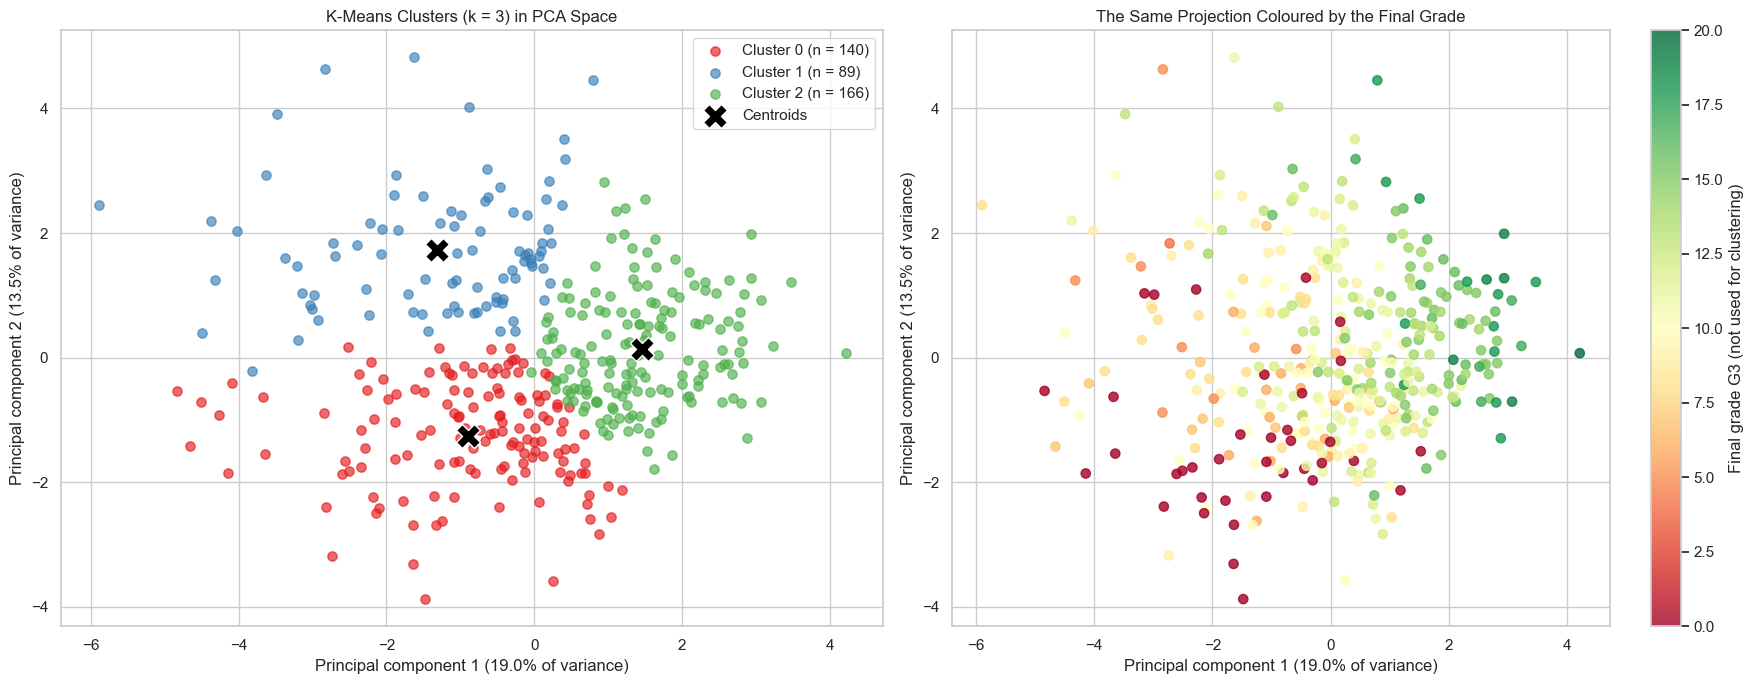

Strongest feature loadings:


,PC1,PC2
G2,0.41,0.23
G1,0.41,0.22
failures,-0.36,-0.12
Walc,-0.33,0.42
Dalc,-0.29,0.42
Medu,0.25,0.39


In [7]:
# 2D PCA projection for visualization (PCA is only used for plotting, not for clustering)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(centers_scaled)
var1, var2 = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
palette = sns.color_palette("Set1", BEST_K)
for c in range(BEST_K):
    m = labels == c
    axes[0].scatter(X_pca[m, 0], X_pca[m, 1], s=45, alpha=0.65, color=palette[c], label=f"Cluster {c} (n = {m.sum()})")
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], marker="X", s=300, color="black", edgecolor="white", label="Centroids")
axes[0].set_title(f"K-Means Clusters (k = {BEST_K}) in PCA Space")
axes[0].set_xlabel(f"Principal component 1 ({var1:.1f}% of variance)")
axes[0].set_ylabel(f"Principal component 2 ({var2:.1f}% of variance)")
axes[0].legend()

sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df["G3"], cmap="RdYlGn", s=45, alpha=0.8)
plt.colorbar(sc, ax=axes[1], label="Final grade G3 (not used for clustering)")
axes[1].set_title("The Same Projection Coloured by the Final Grade")
axes[1].set_xlabel(f"Principal component 1 ({var1:.1f}% of variance)")
axes[1].set_ylabel(f"Principal component 2 ({var2:.1f}% of variance)")
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(pca.components_.T, index=CLUSTER_FEATURES, columns=["PC1", "PC2"])
print("Strongest feature loadings:")
display(loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index).head(6).round(2))

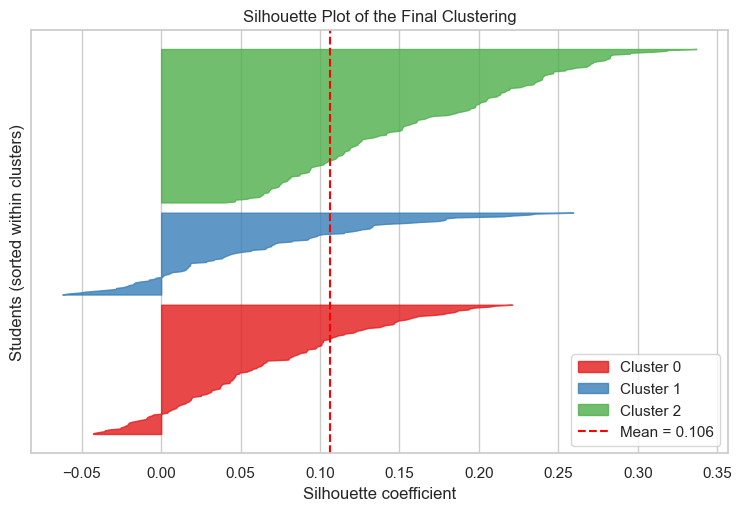

In [8]:
# Silhouette plot: how well each student fits its own cluster
sil_values = silhouette_samples(X_scaled, labels)
fig, ax = plt.subplots(figsize=(9, 5.5))
y_lower = 10
for c in range(BEST_K):
    vals = np.sort(sil_values[labels == c])
    ax.fill_betweenx(np.arange(y_lower, y_lower + len(vals)), 0, vals, color=palette[c], alpha=0.8, label=f"Cluster {c}")
    y_lower += len(vals) + 10
ax.axvline(sil_values.mean(), color="red", linestyle="--", label=f"Mean = {sil_values.mean():.3f}")
ax.set_title("Silhouette Plot of the Final Clustering")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Students (sorted within clusters)")
ax.set_yticks([])
ax.legend()
plt.show()

## 5. Stability Check & Comparison with Hierarchical Clustering

Because the cluster structure is weak, we verify that the solution is not an accident of one sample or one algorithm:
- **Subsample stability:** fit K-Means on random 80% subsamples, assign all students to the nearest centroid and compare with the full-data labels using the Adjusted Rand Index (ARI; 1 = identical partitions, 0 = random agreement).
- **Algorithm comparison:** compare with Ward hierarchical clustering with the same k.

In [9]:
rng = np.random.default_rng(RANDOM_STATE)
ari_scores = []
for _ in range(30):
    idx = rng.choice(len(X_scaled), size=int(0.8 * len(X_scaled)), replace=False)
    km_sub = KMeans(n_clusters=BEST_K, n_init=10, random_state=int(rng.integers(1e6))).fit(X_scaled[idx])
    ari_scores.append(adjusted_rand_score(kmeans.labels_, km_sub.predict(X_scaled)))

ward_labels = AgglomerativeClustering(n_clusters=BEST_K, linkage="ward").fit_predict(X_scaled)

stability = pd.DataFrame({
    "value": {
        "K-Means subsample stability (mean ARI, 30 runs)": np.mean(ari_scores),
        "K-Means subsample stability (min ARI)": np.min(ari_scores),
        "Agreement K-Means vs Ward (ARI)": adjusted_rand_score(kmeans.labels_, ward_labels),
        "Silhouette K-Means": silhouette_score(X_scaled, labels),
        "Silhouette Ward": silhouette_score(X_scaled, ward_labels),
    }
})
stability.round(3)

,value
"K-Means subsample stability (mean ARI, 30 runs)",0.735
K-Means subsample stability (min ARI),0.288
Agreement K-Means vs Ward (ARI),0.235
Silhouette K-Means,0.106
Silhouette Ward,0.050


**Reading the results:** on average the K-Means solution is reproduced reasonably well on 80% subsamples (mean ARI of about 0.7), but the worst subsample agrees only weakly, so individual students near cluster borders can switch groups. Ward clustering agrees only weakly with K-Means (low ARI, lower silhouette), which confirms that the structure is weak and algorithm-dependent. The conclusions below should therefore be treated as exploratory.

## 6. Cluster Profiles & Business Insights

The tables below describe each cluster in the **original units** (not standardized). `G3` and the binary variables were not used for fitting, so they provide an independent check on whether the clusters are meaningful.

In [10]:
profile = df_clusters.groupby("cluster")[CLUSTER_FEATURES].mean().T
profile.columns = [f"Cluster {c}" for c in profile.columns]
profile.round(2)

,Cluster 0,Cluster 1,Cluster 2
age,16.89,16.94,16.40
Medu,1.91,3.10,3.27
Fedu,1.81,2.82,2.96
traveltime,1.58,1.62,1.25
studytime,2.00,1.73,2.23
failures,0.64,0.38,0.05
famrel,3.94,3.76,4.04
freetime,3.06,3.75,3.11
goout,2.89,4.03,2.80
Dalc,1.21,2.62,1.10


In [11]:
outcome = df_clusters.groupby("cluster").agg(
    students=("G3", "size"),
    mean_G3=("G3", "mean"),
    pass_rate=("G3", lambda s: (s >= 10).mean()),
    share_G3_zero=("G3", lambda s: (s == 0).mean()),
    share_male=("sex", lambda s: 1 - s.mean()),
    share_urban=("address", "mean"),
    wants_higher_ed=("higher", "mean"),
    school_support=("schoolsup", "mean"),
    romantic=("romantic", "mean"),
    paid_classes=("paid", "mean"),
)
outcome.index = [f"Cluster {c}" for c in outcome.index]
outcome.round(2)

,students,mean_G3,pass_rate,share_G3_zero,share_male,share_urban,wants_higher_ed,school_support,romantic,paid_classes
Cluster 0,140,7.38,0.44,0.21,0.31,0.69,0.90,0.16,0.37,0.36
Cluster 1,89,9.87,0.61,0.04,0.69,0.73,0.94,0.12,0.37,0.55
Cluster 2,166,13.27,0.90,0.02,0.49,0.88,0.99,0.10,0.28,0.49


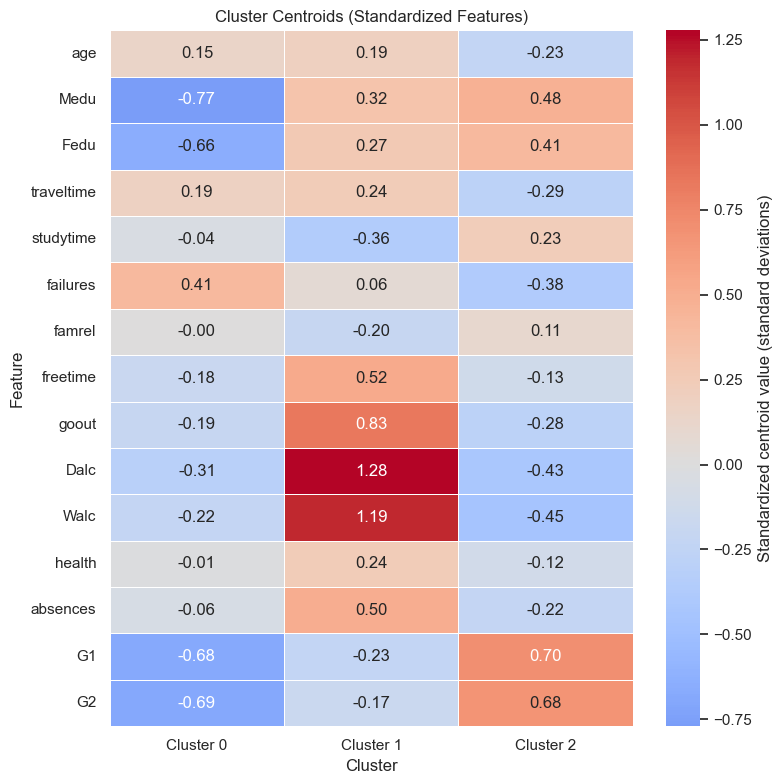

In [12]:
# Standardized centroids: how far each cluster is from the overall average (in standard deviations)
centroid_df = pd.DataFrame(centers_scaled, columns=CLUSTER_FEATURES, index=[f"Cluster {c}" for c in range(BEST_K)]).T

plt.figure(figsize=(8, 8))
sns.heatmap(centroid_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5,
            cbar_kws={"label": "Standardized centroid value (standard deviations)"})
plt.title("Cluster Centroids (Standardized Features)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

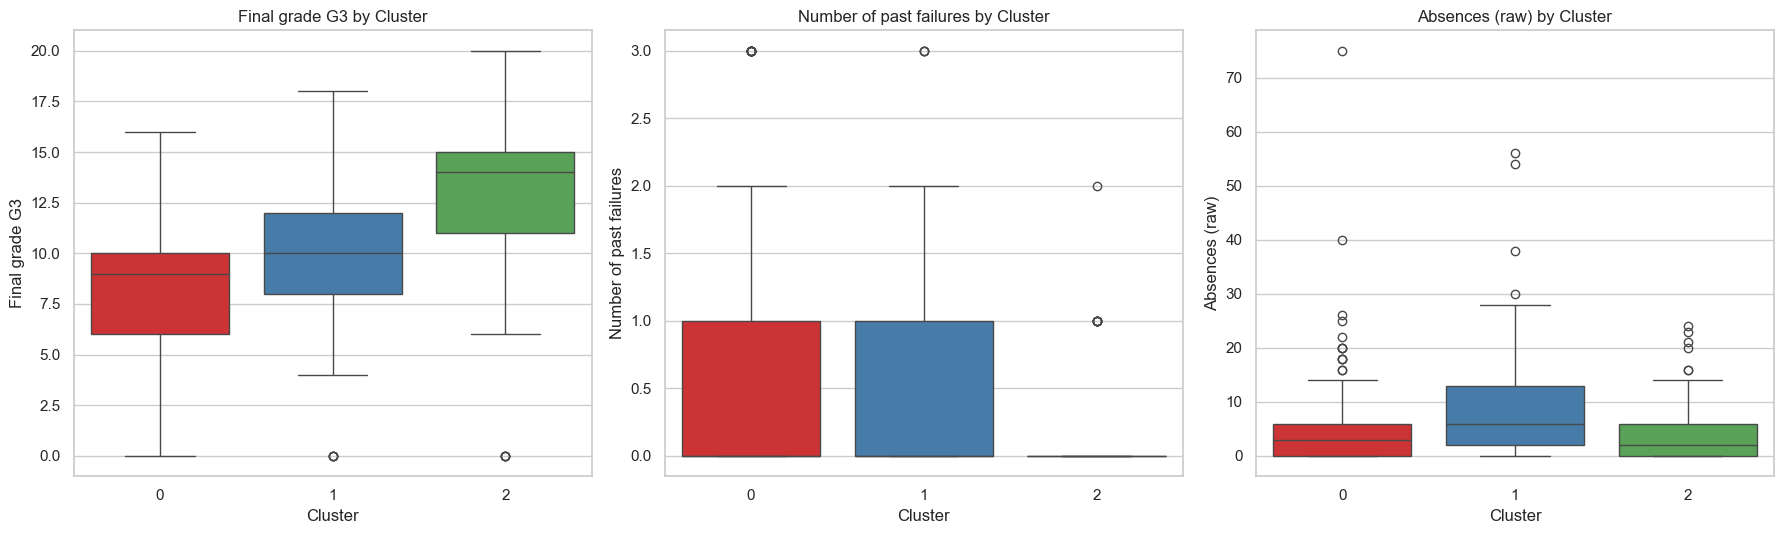

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, col, label in zip(axes, ["G3", "failures", "absences"], ["Final grade G3", "Number of past failures", "Absences (raw)"]):
    sns.boxplot(data=df_clusters, x="cluster", y=col, palette="Set1", ax=ax)
    ax.set_title(f"{label} by Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(label)
plt.tight_layout()
plt.show()

### Interpretation and business insights

The cluster numbers are ordered by mean `G2`, so Cluster 0 has the lowest earlier grades. The figures below refer to this notebook's run (`random_state = 42`).

| Cluster | Size | Profile | Outcome (G3, not used for clustering) |
|---|---|---|---|
| **0 - Struggling students** | 140 (35%) | Lowest `G1`/`G2`, most past failures, lowest parental education, long travel time (about the same as Cluster 1), mostly female (about 69%) | Mean G3 of 7.4, pass rate 44%, and 21% with `G3 = 0` (probable dropouts) |
| **1 - Social, high-alcohol, high-absence students** | 89 (23%) | Average grades, but the most going out, free time and alcohol use (`Dalc`, `Walc`), the most absences (about 9), mostly male (about 69%), the highest use of paid classes | Mean G3 of 9.9, pass rate 61%, few dropouts (4%) |
| **2 - Focused achievers** | 166 (42%) | Highest grades, almost no past failures, well-educated parents, shortest travel time, most urban, little alcohol use, most study time | Mean G3 of 13.3, pass rate 90% |

**What this means in practice**
- **Cluster 0 is the priority group for support.** It contains most of the students at risk of failing or dropping out. Candidates for action: early tutoring and remedial classes triggered by the first low grades or a past failure, outreach to families with limited educational background, and attention to long commutes. Only a small share of these students use the school's educational support (16%), so a more proactive offer could reach many more.
- **Cluster 1 needs a behavioural rather than an academic intervention.** These students perform on average but combine heavy social activity, alcohol use and frequent absences, which are risk factors for later decline. Attendance monitoring and alcohol-prevention programmes are more fitting than extra teaching.
- **Cluster 2 is low-risk.** These students can be involved as peer tutors or mentors, and offered enrichment instead of remediation.

**Caveats:** the separation between clusters is weak (silhouette of about 0.1) and only moderately stable, so these segments are exploratory descriptions. `G1` and `G2` were used for clustering, so the grade differences between clusters are partly built in; the independent evidence is that `G3`, the dropout share and the pass rate, which were not used, differ strongly between the clusters. The clusters describe associations and do not show causes (for example, the gender composition of Clusters 0 and 1 should not be read as a causal effect of gender).

## 7. Export (Optional)

The cluster label of every student can be saved for further analysis. This is a *derived, descriptive* column and should not be used as a feature to predict `G3` in other notebooks.

In [14]:
OUTPUT_PATH = DATA_PATH.parent / "student_clusters.csv"
df_clusters[["cluster"]].to_csv(OUTPUT_PATH, index_label="row_id")
print(f"Saved cluster labels to: {OUTPUT_PATH.resolve()}")

Saved cluster labels to: A:\US\Semestr5\Szkoła Zimowa\Projekt\Repo\Data-science\data\student_clusters.csv
